In [1]:
!pip install geopandas

Defaulting to user installation because normal site-packages is not writeable


In [2]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
import json 
from shapely import wkt 
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose

import glob
import os
import csv
import ast

from math import sqrt
import calplot
from pathlib import Path
from matplotlib.ticker import PercentFormatter

In [3]:
DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)

In [4]:
import logging

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import warnings

warnings.filterwarnings(
    "ignore",
    message="This figure includes Axes that are not compatible with tight_layout"
)

### Reading Temp & Precip  (using 6km buffer version) 

In [5]:
temp_all = pd.read_csv(DATA_DIR / 'processed_weather_data/temp_all_years_6km_buffer.csv').drop(columns = ['Unnamed: 0'])
temp_all['time'] = pd.to_datetime(temp_all['time'])

precip_all = pd.read_csv(DATA_DIR / 'processed_weather_data/precip_all_years_6km_buffer.csv').drop(columns = ['Unnamed: 0'])
precip_all['time'] = pd.to_datetime(precip_all['time'])

### Wind (6km) 

In [6]:
hourly_wind_df = pd.read_csv(DATA_DIR / 'processed_weather_data/ea_hourly_wind_avg_6km.csv').drop(columns=['Unnamed: 0'])

hourly_wind_df['Timestamp'] = pd.to_datetime(hourly_wind_df['Timestamp'])
hourly_wind_df = hourly_wind_df.rename(columns = {'Timestamp':'time'})
hourly_wind_df['Date'] = hourly_wind_df['time'].dt.date

### Lightning (6km aligned) 

In [7]:
hourly_lightning_df = pd.read_csv(DATA_DIR / 'processed_weather_data/ea_hourly_lightning_avg_6km_buffer_aligned.csv').drop(columns=['Unnamed: 0'])
hourly_lightning_df['Timestamp'] = pd.to_datetime(hourly_lightning_df['Timestamp'])
hourly_lightning_df = hourly_lightning_df.rename(columns = {'Timestamp':'time'})
hourly_lightning_df['Date'] = hourly_lightning_df['time'].dt.date

### Extreme Definitions 

### Temp 

In [8]:
temp_all['Date'] = temp_all['time'].dt.floor('D')

# Hot hour flag
temp_all['Hot_Hour'] = temp_all['Temp'] > 32

# Group by EA and Date, and count Hot_Hour sum
daily_hot_hours = (
    temp_all.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Hot_Hour': 'sum'})
)

daily_hot_hours = daily_hot_hours.rename(columns={'Hot_Hour': 'Num_Hot_Hours'})

### Precip 

In [9]:
precip_all['Date'] = precip_all['time'].dt.floor('D')  

# Group by EA and Date, sum Precip
daily_precip = (
    precip_all.groupby(['ea_code9ch', 'Date'], as_index=False)
      .agg({'Precip': 'sum'})
)

### Wind 

In [10]:
# Windy hour flag
hourly_wind_df['Windy_Hour'] = hourly_wind_df['Wind Gusts (m/s)'] > 5.93

# Group by EA and Date, and count Windy_Hour sum
daily_windy_hours = (
    hourly_wind_df.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Windy_Hour': 'sum'})
)

daily_windy_hours = daily_windy_hours.rename(columns={'Windy_Hour': 'Num_Windy_Hours'})

### Lightning 

In [11]:
daily_lightning_per_ea = hourly_lightning_df.groupby(['ea_code9ch', 'Date'])['Lightning Events'].sum().reset_index()

## Percentiles 

In [12]:
### 90th ### 
hot_hrs_90_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.90)
temp_90_thresh = temp_all['Temp'].quantile(0.90)

precip_90_thresh = daily_precip['Precip'].quantile(0.90)
lightning_90_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.90)

windy_hrs_90_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.90)
wind_90_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.90)


### 95th ### 
hot_hrs_95_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.95)
temp_95_thresh = temp_all['Temp'].quantile(0.95)

precip_95_thresh = daily_precip['Precip'].quantile(0.95)
lightning_95_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.95)

windy_hrs_95_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.95)
wind_95_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.95)


### 99th ### 
hot_hrs_99_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.99)
temp_99_thresh = temp_all['Temp'].quantile(0.99)

precip_99_thresh = daily_precip['Precip'].quantile(0.99)
lightning_99_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.99)

windy_hrs_99_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.99)
wind_99_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.99)

#### Dictionary for percentiles 

In [13]:
# Percentile Threshold dictionaries 
temp_thresh_dict = {
    '90': temp_90_thresh,
    '95': temp_95_thresh,
    '99': temp_99_thresh
}

hot_hrs_thresh_dict = {
    '90': hot_hrs_90_thresh,
    '95': hot_hrs_95_thresh,
    '99': hot_hrs_99_thresh
}

precip_thresh_dict = {
    '90': precip_90_thresh,
    '95': precip_95_thresh,
    '99': precip_99_thresh
}

wind_thresh_dict = {
    '90': wind_90_thresh,
    '95': wind_95_thresh,
    '99': wind_99_thresh
}

windy_hrs_thresh_dict = {
    '90': windy_hrs_90_thresh,
    '95': windy_hrs_95_thresh,
    '99': windy_hrs_99_thresh
}

lightning_thresh_dict = {
    '90': 1,   # at least 1 lightning strike 
    '95': lightning_95_thresh,
    '99': lightning_99_thresh
}

## Functions 

In [14]:
## Specify Outage Duration (to be classified as outage or not) 

In [15]:
def flag_outage_hours(df, threshold):
    
    df = df.copy()
    df['Outage_Flag'] = df['outage_mins'] >= threshold
    df['Outage_Dur'] = round( (threshold/60), 2)
    df = df[['time', 'site_id', 'Outage_Flag', 'Outage_Dur']]
    
    return df

In [16]:
def prepare_hourly_df_TPLW_n_outage_data(ea_row, temp_df, precip_df, lightning_df, wind_df, pqr_df, outage_threshold):
    ea = ea_row['ea_code9ch']
    site_list = ea_row['Intersecting_Sites']

    all_merged = []

    for site_id in site_list:
        site_id = int(site_id)

        # Filter temperature
        temp_filt = (
            temp_df[temp_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
        )
        if 'Hot_Hour' in temp_filt.columns:
            temp_filt = temp_filt.drop(columns=['Hot_Hour'])

        temp_filt['time'] = temp_filt['time'].astype('datetime64[ns]')

        # Filter precipitation
        precip_filt = (
            precip_df[precip_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
        )
        precip_filt['time'] = precip_filt['time'].astype('datetime64[ns]')
        precip_filt = precip_filt[['time', 'Precip']]

        # Merge temp and precip
        merged = temp_filt.merge(precip_filt, on='time', how='outer')

        # Filter lightning and outer join
        lightning_filt = (
            lightning_df[lightning_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
            [['time', 'Lightning Events']]
        )
        merged = merged.merge(lightning_filt, on='time', how='outer')
        merged['Lightning Events'] = merged['Lightning Events'].fillna(0)

        ## Merge with Wind (inner merge) 
        wind_filt = (
            wind_df[wind_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
        )
        wind_filt = wind_filt[['time', 'Wind Gusts (m/s)']]  
        wind_filt['time'] = wind_filt['time'].astype('datetime64[ns]')

        # Merge temp and precip
        merged = merged.merge(wind_filt, on='time', how='inner')
     
        # Filter outage data and flag
        pqr_filt = (
            pqr_df[pqr_df['site_id'] == site_id]
            .reset_index(drop=True)[['time', 'site_id', 'outage_events', 'outage_mins']]
        )
        flagged_outages = flag_outage_hours(pqr_filt, threshold=outage_threshold)

        # Inner join outages
        merged = merged.merge(flagged_outages, on='time', how='inner')

        # Add identifiers
        merged['ea_code9ch'] = ea
        merged['site_id'] = site_id

        # Reorder columns
        merged = merged[['time', 'Date', 'ea_code9ch', 'site_id', 'Temp', 'Precip', 
                 'Lightning Events', 'Wind Gusts (m/s)', 
                 'Outage_Flag', 'Outage_Dur']]

        all_merged.append(merged)

    return pd.concat(all_merged, ignore_index=True)

In [17]:
def create_daily_summary_extreme_weather_REV(
    df,
    temp_thresh,
    hot_hours_thresh,
    precip_thresh,
    lightning_thresh,
    wind_thresh,
    windy_hours_thresh
):
    df = df.copy()
    df['Date'] = df['time'].dt.date
    df['Hot_hour'] = df['Temp'] > temp_thresh
    df['Windy_Hour'] = df['Wind Gusts (m/s)'] > wind_thresh

    # Aggregate to daily summary per enumeration area
    daily_summary = (
        df.groupby(['Date', 'ea_code9ch'], as_index=False)
          .agg({
              'Precip': 'sum',
              'Lightning Events': 'sum',
              'Hot_hour': 'sum',
              'Windy_Hour': 'sum'
          })
    )

    # Classify each day by condition
    daily_summary['T'] = daily_summary['Hot_hour'] >= hot_hours_thresh
    daily_summary['W'] = daily_summary['Windy_Hour'] >= windy_hours_thresh
    daily_summary['P'] = daily_summary['Precip'] >= precip_thresh
    daily_summary['L'] = daily_summary['Lightning Events'] >= lightning_thresh

    # Add Month and Year-Month columns
    daily_summary['Month'] = pd.to_datetime(daily_summary['Date']).dt.month
    daily_summary['Year_Month'] = pd.to_datetime(daily_summary['Date']).dt.to_period('M').astype(str)

    # --- Specific combinations ---
    daily_summary['TP'] = daily_summary['T'] & daily_summary['P'] 
    daily_summary['TW'] = daily_summary['T'] & daily_summary['W'] 
    daily_summary['TL'] = daily_summary['T'] & daily_summary['L'] 
    daily_summary['PW'] = daily_summary['P'] & daily_summary['W'] 
    daily_summary['PL'] = daily_summary['P'] & daily_summary['L'] 
    daily_summary['WL'] = daily_summary['W'] & daily_summary['L'] 
    daily_summary['PWL'] = daily_summary['P'] & daily_summary['W'] & daily_summary['L'] 

    # --- Print frequency of combinations in days ---
    # print("")
    # print("")
    # combination_cols = ['T', 'P', 'W', 'L', 'TP', 'TW', 'TL', 'PW', 'PL', 'WL', 'PWL']
    # print("\nFrequency of extreme weather combinations (EA-days):")
    # print(daily_summary[combination_cols].sum().sort_values(ascending=False))
    # print("")
    # print("")

    return daily_summary

## --- Extreme Weather per Month Workflow --- 

### EA Names mapped  

In [18]:
ea_names_mapped = pd.read_csv(DATA_DIR / 'miscellaneous/ea_names_mapped.csv')

ea_names_mapped = ea_names_mapped[['ea_code9ch', 'LOC_NAME', 'BASE_NAM', 'geometry']]

### EAs n Sites - *** using new 'EAs_n_Sites' (6km) 

In [19]:
merged_eas_sites = pd.read_csv(DATA_DIR / 'miscellaneous/ea_site_list_6km_buffer.csv')
merged_eas_sites = merged_eas_sites[['ea_code9ch', 'Intersecting_Sites']]

# Convert the string representation of lists to actual lists
merged_eas_sites['Intersecting_Sites'] = merged_eas_sites['Intersecting_Sites'].apply(ast.literal_eval)

In [20]:
# merged_eas_sites['ea_code9ch'].nunique()

In [21]:
filtered_eas_sites_copy = merged_eas_sites

## Outage Workflow 

In [22]:
## 22 
pqr_hourly_22 = pd.read_csv(DATA_DIR / 'miscellaneous/merged_outage_n_voltage_hourly_22_NEW.csv')
pqr_hourly_22['time'] = pd.to_datetime(pqr_hourly_22['time'])
pqr_hourly_22['time'] = pqr_hourly_22['time'].dt.tz_convert(None)

## 23 
pqr_hourly_23 = pd.read_csv(DATA_DIR / 'miscellaneous/merged_outage_n_voltage_hourly_23_NEW.csv')
pqr_hourly_23['time'] = pd.to_datetime(pqr_hourly_23['time'])
pqr_hourly_23['time'] = pqr_hourly_23['time'].dt.tz_convert(None)

pqr_hourly_all = pd.concat([pqr_hourly_22, pqr_hourly_23], ignore_index=True).drop(columns=['Unnamed: 0'])

In [23]:
pqr_hourly_all['site_id'].nunique()

366

## Remove sites with > `10%` missing data & less than 24 months 

In [24]:
sites_to_omit = pd.read_csv(DATA_DIR / 'miscellaneous/complete_site_removal_df.csv')['site_id'].to_list()

pqr_hourly_all_rev = pqr_hourly_all[ ~( pqr_hourly_all['site_id'].isin(sites_to_omit) ) ].reset_index(drop=True)

### Global Workflow - Outages 

In [25]:
filtered_eas_sites_copy_r1 = filtered_eas_sites_copy.copy()

### ***TPLW Dataset***  (Extreme Weather per Month) 

### 95th percentile 

In [26]:
## Outage Duration & Percentile 
dur = 60  # duration in minutes --> doesn't matter here, just focused on the weather variables 
percentile = '95'

# Main loop
results = []

for _, row in filtered_eas_sites_copy_r1.iterrows():
    merged_hourly = prepare_hourly_df_TPLW_n_outage_data(
        row, 
        temp_all, 
        precip_all, 
        hourly_lightning_df, 
        hourly_wind_df, 
        pqr_hourly_all_rev, 
        outage_threshold=dur
    )
    if merged_hourly is not None:
        results.append(merged_hourly)

merged_hourly_data_global = pd.concat(results, ignore_index=True)

In [27]:
hourly_weather = merged_hourly_data_global.drop(columns=['Outage_Flag', 'Outage_Dur', 'site_id'])

In [28]:
hourly_weather['ea_code9ch'].nunique()

214

### Save the TPLW EAs to file 

In [29]:
unique_ea_codes = hourly_weather['ea_code9ch'].unique().tolist()

ea_codes_df = pd.DataFrame(unique_ea_codes, columns=['ea_code9ch'])

In [30]:
# ea_codes_df.to_csv(DATA_DIR / 'miscellaneous/unique_ea_codes_TPLW.csv', index=False)

### Summarize Extreme Weather frequency per day 

In [31]:
daily_extreme_weather_REV = create_daily_summary_extreme_weather_REV(
    hourly_weather, 
    temp_thresh = temp_thresh_dict[percentile], 
    hot_hours_thresh = hot_hrs_thresh_dict[percentile], 
    precip_thresh = precip_thresh_dict[percentile], 
    lightning_thresh = lightning_thresh_dict[percentile],  
    wind_thresh = wind_thresh_dict[percentile], 
    windy_hours_thresh = windy_hrs_thresh_dict[percentile]
)

In [32]:
daily_extreme_weather_REV = daily_extreme_weather_REV[[
            'Date', 'ea_code9ch', 
            'Precip', 'Lightning Events', 'Hot_hour', 'Windy_Hour', 
            'T', 'W', 'P', 'L', 
            'PW', 'PL', 'WL', 'PWL', 
            'Month', 'Year_Month']]

daily_extreme_weather_REV['Date'] = pd.to_datetime(daily_extreme_weather_REV['Date'])

In [33]:
daily_extreme_weather_REV.head()

,Date,ea_code9ch,Precip,Lightning Events,Hot_hour,Windy_Hour,T,W,P,L,PW,PL,WL,PWL,Month,Year_Month
0,2022-01-01,30200002,0.0,0.0,0,0,False,False,False,False,False,False,False,False,1,2022-01
1,2022-01-01,30200012,0.0,0.0,0,0,False,False,False,False,False,False,False,False,1,2022-01
2,2022-01-01,30200013,0.0,0.0,0,0,False,False,False,False,False,False,False,False,1,2022-01
3,2022-01-01,30200014,0.0,0.0,0,0,False,False,False,False,False,False,False,False,1,2022-01
4,2022-01-01,30200015,0.0,0.0,0,0,False,False,False,False,False,False,False,False,1,2022-01


### *** DAILY version: `Proportion` of EAs per Weather Event    

In [34]:
event_cols = ['T', 'P', 'W', 'L', 'PW', 'PL', 'WL', 'PWL']

daily_event_pct = (
    daily_extreme_weather_REV
    .groupby('Date')[event_cols]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={
        col: f'{col}_pct_nonzero'
        for col in event_cols
    })
    .round(2)
)

### Day version - total event days / total EA-days 

In [35]:
import pandas as pd

def normalize_daily_extremes_by_eas(
    df,
    date_col="Date",
    num_ea=214,
    return_percent=False
):
    out = df.copy()

    # Ensure datetime
    out[date_col] = pd.to_datetime(out[date_col])

    # Columns to normalize
    value_cols = [
        c for c in out.columns
        if c != date_col
    ]

    # Normalize by total possible EAs
    out[value_cols] = out[value_cols].div(num_ea)

    # Convert to %
    if return_percent:
        out[value_cols] *= 100

    return out

In [36]:
event_cols = ['T', 'P', 'W', 'L', 'PW', 'PL', 'WL', 'PWL']

# Total event occurrence per Year-Month
day_total_all_eas = (
    daily_extreme_weather_REV
    .groupby('Date', as_index=False)[event_cols]
    .sum()
)

day_total_all_eas_norm = normalize_daily_extremes_by_eas(
    day_total_all_eas,
    date_col='Date',
    num_ea=214,
    return_percent=True
).round(2)

In [37]:
day_total_all_eas_norm.head()

,Date,T,P,W,L,PW,PL,WL,PWL
0,2022-01-01,0.47,0.00,0.0,0.00,0.0,0.0,0.0,0.0
1,2022-01-02,0.00,3.74,0.0,0.00,0.0,0.0,0.0,0.0
2,2022-01-03,4.67,0.00,0.0,0.47,0.0,0.0,0.0,0.0
3,2022-01-04,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0
4,2022-01-05,0.93,0.00,0.0,0.00,0.0,0.0,0.0,0.0


## Calendar Plots  

In [38]:
def plot_extreme_weather_calendar(
    df,
    event_col,
    cmap='YlOrRd',
    save_path=None,
    date_col='Date',

    figsize=(18, 5),

    vmin=0,
    vmax=100,

    # Cell border styling
    linewidth=0.3,
    linecolor='#dddddd',

    # Missing-day color
    fillcolor='white',

    hspace=0.25,

    year_fontsize=14,
    year_fontweight='bold',

    # Optional August-start calendar
    start_august=False,

    # Colorbar controls
    show_colorbar=True,
    cbar_label='% of EAs experiencing event',
    cbar_label_fontsize=12,
    cbar_tick_fontsize=10,

    edge_color = 'grey', 

    # Title
    title='',

    # Force daily frequency
    force_daily=True,

    dpi=300
):

    # -------------------------------------------------
    # Copy dataframe
    # -------------------------------------------------
    plot_df = df.copy()

    plot_df[date_col] = pd.to_datetime(plot_df[date_col])

    # -------------------------------------------------
    # Optional August-start calendar
    # -------------------------------------------------
    if start_august:

        plot_df['_plot_date'] = plot_df[date_col]

        # Shift Jan-Jul forward by 1 year
        mask = plot_df['_plot_date'].dt.month < 8

        plot_df.loc[mask, '_plot_date'] = (
            plot_df.loc[mask, '_plot_date']
            + pd.DateOffset(years=1)
        )

        plot_date_col = '_plot_date'

    else:

        plot_date_col = date_col

    # -------------------------------------------------
    # Create series
    # -------------------------------------------------
    event_series = (
        plot_df
        .set_index(plot_date_col)[event_col]
        .sort_index()
    )

    # -------------------------------------------------
    # Ensure daily frequency
    # -------------------------------------------------
    if force_daily:

        event_series = event_series.asfreq(
            'D',
            fill_value=0
        )

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, axes = calplot.calplot(
        event_series,

        cmap=cmap,

        figsize=figsize,

        colorbar=show_colorbar,

        suptitle=title,

        vmin=vmin,
        vmax=vmax,

        linewidth=linewidth,
        linecolor=linecolor,
        edgecolor=edge_color,

        fillcolor=fillcolor,

        yearlabel_kws={
            'fontsize': year_fontsize,
            'fontweight': year_fontweight
        },

        gridspec_kws={
            'hspace': hspace
        }, 
        
        dropzero=True,
        
    )

    # -------------------------------------------------
    # Colorbar formatting
    # -------------------------------------------------
    if show_colorbar:

        cbar = fig.axes[-1]

        cbar.set_ylabel(
            cbar_label,
            fontsize=cbar_label_fontsize,
            fontweight='bold',
            labelpad=15
        )

        cbar.tick_params(
            labelsize=cbar_tick_fontsize
        )

    # -------------------------------------------------
    # Save
    # -------------------------------------------------
    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight'
        )

    plt.show()

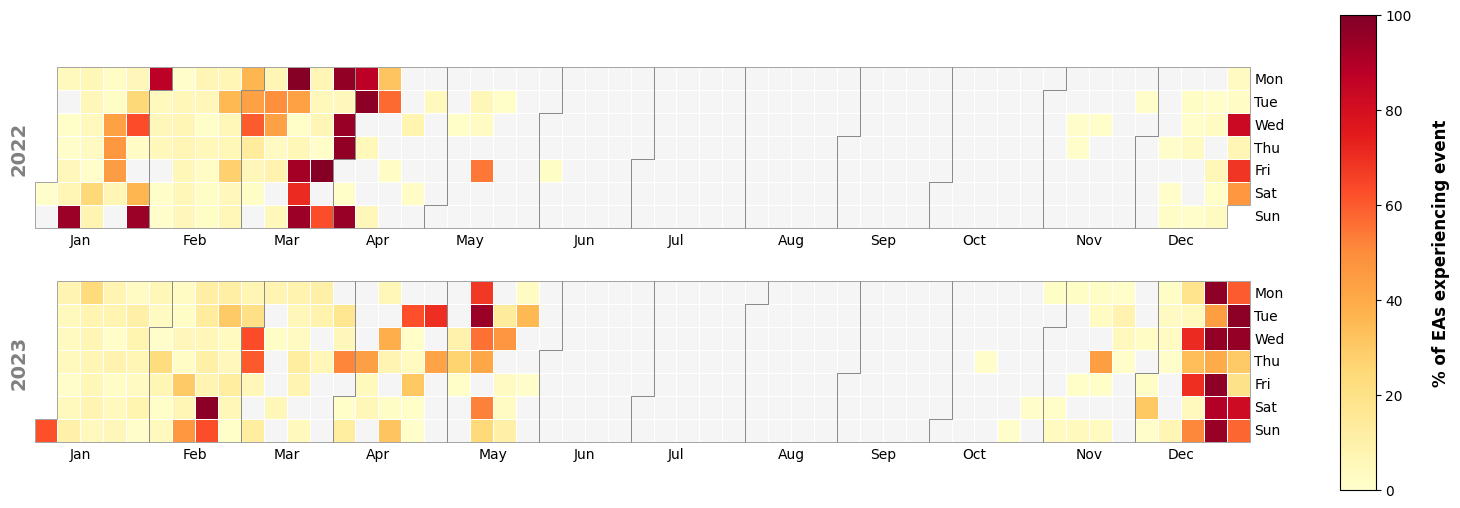

In [39]:
plot_extreme_weather_calendar(
    day_total_all_eas_norm,
    event_col='T',
    cmap='YlOrRd',
    
    # Cell border styling
    linewidth=0.5, 
    linecolor='white',

    # Missing-day color
    fillcolor='whitesmoke',
    
    start_august=False,
    title='', 
    show_colorbar=True,
    # save_path = PLOTS_DIR / 'PWL_calendar_plot.png'
)

## Multi-panel plot  

In [40]:
import math
import string

import calplot
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import pandas as pd


def plot_extreme_weather_calendar_panels(
    df,
    event_cols,
    date_col='Date',
    ncols=2,

    # Figure sizing
    panel_width=10,
    panel_height=4.0,

    # Discrete color scale
    cmap='YlOrRd',
    cbar_boundaries=(0, 20, 40, 60, 80, 100),

    # Calendar cell styling
    linewidth=0.5,
    linecolor='white',
    edge_color='grey',
    fillcolor='whitesmoke',

    # Date handling
    force_daily=True,
    missing_value=None,

    # Year labels
    year_fontsize=12,
    year_fontweight='bold',
    year_labelpad=12,

    # Panel labels
    panel_labels=None,
    panel_label_x=0.0,
    panel_label_y=1.10,
    panel_label_fontsize=13,
    panel_label_fontweight='bold',
    panel_label_ha='left',
    panel_label_va='bottom',

    # Spacing
    hspace_within_panel=0.20,
    hspace_between_panels=0.40,
    wspace_between_panels=0.12,

    # Figure margins
    figure_left=0.05,
    figure_top=0.97,
    figure_bottom=0.08,

    # Shared colorbar
    show_colorbar=True,
    cbar_label='% of EAs experiencing event',
    cbar_label_fontsize=12,
    cbar_tick_fontsize=10,
    cbar_labelpad=15,
    cbar_drawedges=True,

    # Colorbar position
    cbar_gap=0.045,
    cbar_width=0.018,
    cbar_right_margin=0.035,

    # No-event legend
    show_no_event_legend=True,
    no_event_label='No event',
    no_event_legend_loc='lower center',
    no_event_legend_bbox=(0.5, 0.01),
    no_event_legend_fontsize=11,
    no_event_patch_edgecolor='grey',

    # Overall title
    suptitle=None,
    suptitle_fontsize=16,
    suptitle_y=0.995,

    # Output
    save_path=None,
    dpi=300
):
    """
    Plot multiple extreme-weather calendars in a multi-panel layout.

    Each event occupies one panel. Within each panel, years are arranged
    vertically. All panels share a discrete, full-height colorbar.

    With dropzero=True, days with values of zero are displayed using
    `fillcolor`. Positive values are displayed using the binned colormap.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing a date column and event columns.

    event_cols : list of str
        Event columns to plot, such as:
        ['T', 'P', 'W', 'L', 'PW', 'WL', 'PL', 'PWL'].

    cbar_boundaries : sequence of numbers
        Boundaries of the discrete color intervals. For example,
        (0, 20, 40, 60, 80, 100) creates five color bins.

    cbar_gap : float
        Horizontal space between the rightmost calendar axis and colorbar,
        expressed in figure coordinates.

    cbar_width : float
        Width of the colorbar in figure coordinates.

    cbar_right_margin : float
        Space between the colorbar and the right edge of the figure.
    """

    # -------------------------------------------------
    # Validate inputs and prepare data
    # -------------------------------------------------
    plot_df = df.copy()
    plot_df[date_col] = pd.to_datetime(plot_df[date_col])

    missing_cols = [
        col for col in event_cols
        if col not in plot_df.columns
    ]

    if missing_cols:
        raise ValueError(
            f"Columns not found in dataframe: {missing_cols}"
        )

    if len(cbar_boundaries) < 2:
        raise ValueError(
            "cbar_boundaries must contain at least two values."
        )

    if ncols < 1:
        raise ValueError("ncols must be at least 1.")

    # Average duplicate dates, if present
    daily_df = (
        plot_df
        .groupby(date_col, as_index=False)[event_cols]
        .mean()
        .sort_values(date_col)
    )

    # -------------------------------------------------
    # Ensure a daily date index
    # -------------------------------------------------
    if force_daily:

        full_dates = pd.date_range(
            start=daily_df[date_col].min(),
            end=daily_df[date_col].max(),
            freq='D'
        )

        daily_df = (
            daily_df
            .set_index(date_col)
            .reindex(full_dates)
        )

        daily_df.index.name = date_col

        if missing_value is not None:
            daily_df[event_cols] = (
                daily_df[event_cols]
                .fillna(missing_value)
            )

    else:
        daily_df = daily_df.set_index(date_col)

    years = sorted(
        daily_df.index.year.unique()
    )

    # -------------------------------------------------
    # Panel labels
    # -------------------------------------------------
    if panel_labels is None:
        panel_labels = list(
            string.ascii_lowercase[:len(event_cols)]
        )

    if len(panel_labels) < len(event_cols):
        raise ValueError(
            "panel_labels must contain at least one label per event."
        )

    # -------------------------------------------------
    # Create a discrete colormap
    # -------------------------------------------------
    boundaries = list(cbar_boundaries)
    number_of_bins = len(boundaries) - 1

    base_cmap = mpl.colormaps[cmap]

    if number_of_bins == 1:
        discrete_colors = [base_cmap(0.7)]

    else:
        discrete_colors = [
            base_cmap(i / (number_of_bins - 1))
            for i in range(number_of_bins)
        ]

    discrete_cmap = mpl.colors.ListedColormap(
        discrete_colors,
        name=f'{cmap}_discrete'
    )

    discrete_norm = mpl.colors.BoundaryNorm(
        boundaries,
        ncolors=number_of_bins,
        clip=True
    )

    vmin = boundaries[0]
    vmax = boundaries[-1]

    # -------------------------------------------------
    # Determine figure layout
    # -------------------------------------------------
    number_of_events = len(event_cols)
    number_of_rows = math.ceil(
        number_of_events / ncols
    )

    figsize = (
        panel_width * ncols,
        panel_height * number_of_rows
    )

    fig = plt.figure(figsize=figsize)

    # Reserve space on the right for the colorbar
    if show_colorbar:
        plot_right = (
            1
            - cbar_right_margin
            - cbar_width
            - cbar_gap
        )
    else:
        plot_right = 1 - cbar_right_margin

    outer_grid = fig.add_gridspec(
        nrows=number_of_rows,
        ncols=ncols,
        left=figure_left,
        right=plot_right,
        top=figure_top,
        bottom=figure_bottom,
        hspace=hspace_between_panels,
        wspace=wspace_between_panels
    )

    all_axes = []

    # -------------------------------------------------
    # Plot each event
    # -------------------------------------------------
    for event_i, event_col in enumerate(event_cols):

        outer_row = event_i // ncols
        outer_col = event_i % ncols

        inner_grid = outer_grid[
            outer_row,
            outer_col
        ].subgridspec(
            nrows=len(years),
            ncols=1,
            hspace=hspace_within_panel
        )

        event_series = daily_df[event_col]
        panel_axes = []

        for year_i, year in enumerate(years):

            ax = fig.add_subplot(
                inner_grid[year_i, 0]
            )

            panel_axes.append(ax)
            all_axes.append(ax)

            calplot.yearplot(
                event_series,
                year=year,
                ax=ax,
                cmap=discrete_cmap,
                vmin=vmin,
                vmax=vmax,
                linewidth=linewidth,
                linecolor=linecolor,
                edgecolor=edge_color,
                fillcolor=fillcolor,

                # Zero-event days receive fillcolor
                dropzero=True
            )

            ax.set_ylabel(
                str(year),
                fontsize=year_fontsize,
                fontweight=year_fontweight,
                rotation=90,
                labelpad=year_labelpad
            )

        # Use the first year as the reference for panel labels
        reference_ax = panel_axes[0]

        reference_ax.text(
            panel_label_x,
            panel_label_y,
            str(panel_labels[event_i]),
            transform=reference_ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight=panel_label_fontweight,
            ha=panel_label_ha,
            va=panel_label_va
        )

    # -------------------------------------------------
    # Hide unused panel positions
    # -------------------------------------------------
    for empty_i in range(
        number_of_events,
        number_of_rows * ncols
    ):

        outer_row = empty_i // ncols
        outer_col = empty_i % ncols

        empty_ax = fig.add_subplot(
            outer_grid[outer_row, outer_col]
        )

        empty_ax.axis('off')

    # -------------------------------------------------
    # Shared full-height discrete colorbar
    # -------------------------------------------------
    if show_colorbar:

        scalar_map = mpl.cm.ScalarMappable(
            norm=discrete_norm,
            cmap=discrete_cmap
        )

        scalar_map.set_array([])

        # Finalize subplot positions before finding their bounds
        fig.canvas.draw()

        axes_bottom = min(
            ax.get_position().y0
            for ax in all_axes
        )

        axes_top = max(
            ax.get_position().y1
            for ax in all_axes
        )

        axes_right = max(
            ax.get_position().x1
            for ax in all_axes
        )

        # Explicit colorbar axis spanning the full calendar height
        cbar_ax = fig.add_axes([
            axes_right + cbar_gap,
            axes_bottom,
            cbar_width,
            axes_top - axes_bottom
        ])

        cbar = fig.colorbar(
            scalar_map,
            cax=cbar_ax,
            boundaries=boundaries,
            ticks=boundaries,
            spacing='proportional',
            drawedges=cbar_drawedges
        )

        cbar.ax.yaxis.set_major_formatter(
            PercentFormatter(xmax=100, decimals=0)
        )

        cbar.set_label(
            cbar_label,
            fontsize=cbar_label_fontsize,
            fontweight='bold',
            labelpad=cbar_labelpad
        )

        cbar.ax.tick_params(
            labelsize=cbar_tick_fontsize
        )

    # -------------------------------------------------
    # No-event legend
    # -------------------------------------------------
    if show_no_event_legend:

        no_event_patch = Patch(
            facecolor=fillcolor,
            edgecolor=no_event_patch_edgecolor,
            linewidth=0.8,
            label=no_event_label
        )

        fig.legend(
            handles=[no_event_patch],
            loc=no_event_legend_loc,
            bbox_to_anchor=no_event_legend_bbox,
            frameon=False,
            fontsize=no_event_legend_fontsize
        )

    # -------------------------------------------------
    # Overall title
    # -------------------------------------------------
    if suptitle:

        fig.suptitle(
            suptitle,
            fontsize=suptitle_fontsize,
            fontweight='bold',
            y=suptitle_y
        )

    # -------------------------------------------------
    # Save and display
    # -------------------------------------------------
    if save_path is not None:

        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight'
        )

    plt.show()

    return fig, all_axes

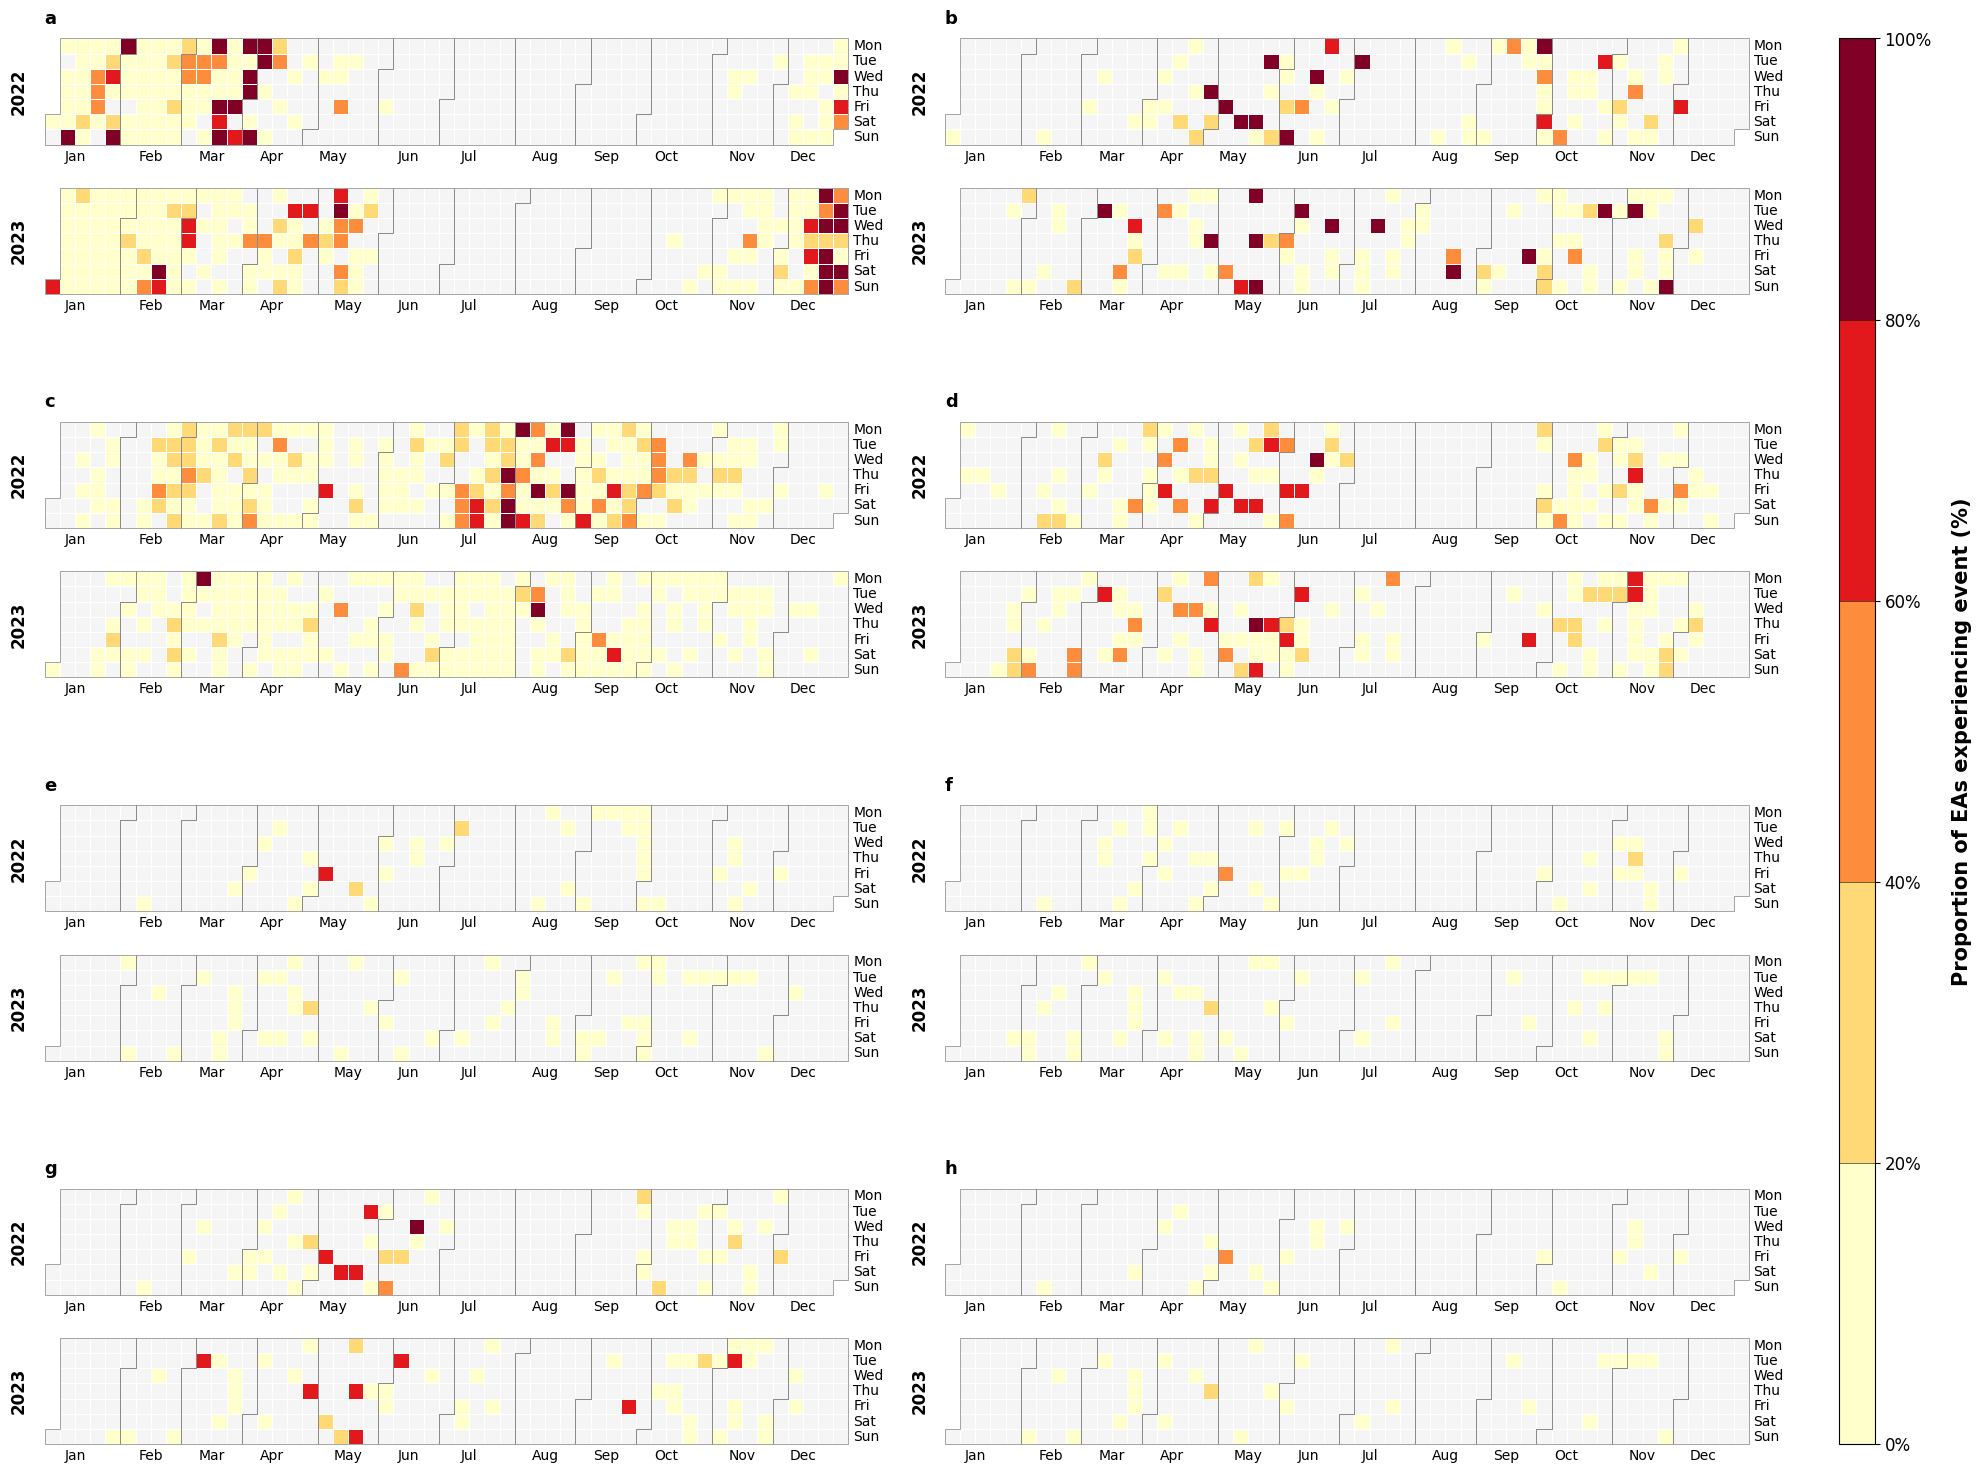

In [41]:
fig, axes = plot_extreme_weather_calendar_panels(
    day_total_all_eas_norm,

    event_cols=[
        'T', 'P',
        'W', 'L',
        'PW', 'WL',
        'PL', 'PWL'
    ],

    # Two event panels per row
    ncols=2,

    # Figure size
    panel_width=10,
    panel_height=4.0,

    # Discrete colorbar
    cmap='YlOrRd',
    cbar_boundaries=(0, 20, 40, 60, 80, 100),

    # Calendar cells
    linewidth=0.5,
    linecolor='white',
    edge_color='grey',

    # Zero-event days
    fillcolor='whitesmoke',

    # Year labels
    year_fontsize=12,
    year_fontweight='bold',

    # Panel letters without parentheses
    panel_labels=list('abcdefgh'),
    panel_label_x=0.0,
    # panel_label_x=-0.01,
    panel_label_y=1.10,
    panel_label_fontsize=13,
    panel_label_fontweight='bold',

    # Spacing within and between panels
    hspace_within_panel=0.20,
    hspace_between_panels=0.40,
    wspace_between_panels=0.12,

    # Full-height colorbar positioning
    cbar_gap=0.045,
    cbar_width=0.018,
    cbar_right_margin=0.035,

    cbar_label='Proportion of EAs experiencing event (%)',
    cbar_label_fontsize=15,
    cbar_tick_fontsize=12,

    # Grey-cell legend
    show_no_event_legend=False,
    no_event_label='No event',
    no_event_legend_bbox=(0.8, 1),

    # Save
    save_path=PLOTS_DIR / 'all_extreme_weather_calendars.png'
)

## Additional Stats 

In [42]:
day_total_all_eas_norm.max()

Date    2023-12-31 00:00:00
T                      98.6
P                     99.53
W                      97.2
L                     81.78
PW                    67.29
PL                    80.37
WL                     47.2
PWL                   45.79
dtype: object

In [43]:
day_total_all_eas_norm["Year"] = day_total_all_eas_norm["Date"].dt.year
day_total_all_eas_norm["Month"] = day_total_all_eas_norm["Date"].dt.month

In [44]:
jan_23 = day_total_all_eas_norm[ (day_total_all_eas_norm['Month'].isin([1])) & (day_total_all_eas_norm['Year']==2023)].reset_index(drop=True)
feb_23 = day_total_all_eas_norm[ (day_total_all_eas_norm['Month'].isin([2])) & (day_total_all_eas_norm['Year']==2023)].reset_index(drop=True)
mar_23 = day_total_all_eas_norm[ (day_total_all_eas_norm['Month'].isin([1])) & (day_total_all_eas_norm['Year']==2023)].reset_index(drop=True)
dec_23 = day_total_all_eas_norm[ (day_total_all_eas_norm['Month'].isin([12])) & (day_total_all_eas_norm['Year']==2023)].reset_index(drop=True)

In [45]:
# display(jan_23[jan_23['T']>0])

# display(feb_23[feb_23['T']>0])

# display(mar_23[mar_23['T']>0])

# display(dec_23[dec_23['T']>0])

In [46]:
# jan_23[jan_23['T']>40]

In [47]:
# dec_23[dec_23['T']>40]

In [48]:
# display((jan_23)[['T']].describe())

# display((dec_23)[['T']].describe())

### Precip 

In [49]:
may_23 = day_total_all_eas_norm[ (day_total_all_eas_norm['Month'].isin([5])) & (day_total_all_eas_norm['Year']==2023)].reset_index(drop=True)
oct_23 = day_total_all_eas_norm[ (day_total_all_eas_norm['Month'].isin([10])) & (day_total_all_eas_norm['Year']==2023)].reset_index(drop=True)

minor_23 = day_total_all_eas_norm[ (day_total_all_eas_norm['Month'].isin([9,10,11])) & (day_total_all_eas_norm['Year']==2023)].reset_index(drop=True)
major_23 = day_total_all_eas_norm[ (day_total_all_eas_norm['Month'].isin([4,5,6,7])) & (day_total_all_eas_norm['Year']==2023)].reset_index(drop=True)

In [50]:
# may_23[may_23['P']>30]

In [51]:
# oct_23[oct_23['P']>30]

In [52]:
# (major_23[major_23['P']>30])

In [53]:
# (major_23[major_23['L']>30])

In [54]:
# (minor_23[minor_23['P']>30])

In [55]:
# (minor_23[minor_23['L']>30])

### Wind 

In [56]:
mar_22 = day_total_all_eas_norm[ (day_total_all_eas_norm['Month'].isin([3])) & (day_total_all_eas_norm['Year']==2022)].reset_index(drop=True)
jul_22 = day_total_all_eas_norm[ (day_total_all_eas_norm['Month'].isin([7])) & (day_total_all_eas_norm['Year']==2022)].reset_index(drop=True)
aug_22 = day_total_all_eas_norm[ (day_total_all_eas_norm['Month'].isin([8])) & (day_total_all_eas_norm['Year']==2022)].reset_index(drop=True)
sept_22 = day_total_all_eas_norm[ (day_total_all_eas_norm['Month'].isin([9])) & (day_total_all_eas_norm['Year']==2022)].reset_index(drop=True)

In [57]:
# (mar_22[mar_22['W']>0])

In [58]:
# (jul_22[jul_22['W']>0])

In [59]:
# (sept_22[sept_22['W']>0])

In [60]:
# (aug_22[aug_22['W']>0])

### Summary Stats 

In [61]:
import pandas as pd

GHANA_SEASONS = {
    12: "Dry",  1: "Dry",  2: "Dry",  3: "Dry",
     4: "Major Rainy",  5: "Major Rainy",  6: "Major Rainy",  7: "Major Rainy",
     8: "Transition",
     9: "Minor Rainy", 10: "Minor Rainy", 11: "Minor Rainy",
}

# Ordered for display
SEASON_ORDER = ["Dry", "Major Rainy", "Transition", "Minor Rainy"]

def summarise_event_days(
    df: pd.DataFrame,
    event: str,
    threshold: float = 0.0,
    season_map: dict = GHANA_SEASONS,
    date_col: str = "Date",
) -> pd.DataFrame:
    """
    Summarise days per season where ≥ threshold % of EAs experienced `event`.

    Parameters
    ----------
    df        : day_total_all_eas_norm (Date + event-proportion columns)
    event     : column name, e.g. 'T', 'PW', 'PWL'
    threshold : minimum % of EAs required (default 0 → any nonzero day)
    season_map: month → season label mapping (defaults to GHANA_SEASONS)
    date_col  : name of the date column

    Returns
    -------
    DataFrame: Season | n_days | pct_of_season_days | mean_ea_pct | median_ea_pct | max_ea_pct
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df["_season"] = df[date_col].dt.month.map(season_map)

    season_totals = df.groupby("_season")[date_col].count().rename("total_days")

    summary = (
        df[df[event] >= threshold]
        .groupby("_season")[event]
        .agg(
            n_days="count",
            mean_ea_pct="mean",
            # median_ea_pct="median",
            # max_ea_pct="max",
        )
        .join(season_totals)
        .assign(pct_of_season_days=lambda x: 100 * x["n_days"] / x["total_days"])
        .drop(columns="total_days")
        .reindex(SEASON_ORDER)          # consistent row order
        .reset_index()
        .rename(columns={"_season": "Season"})
    )

    return summary.round(2)

In [62]:
# pct_one_ea = (1/214)*100

In [63]:
# summarise_event_days(day_total_all_eas_norm, event='T', threshold=pct_one_ea)

In [64]:
# summarise_event_days(day_total_all_eas_norm, event='PW', threshold=pct_one_ea)

In [65]:
# summarise_event_days(day_total_all_eas_norm, event='WL', threshold=pct_one_ea)

In [66]:
# summarise_event_days(day_total_all_eas_norm, event='PL', threshold=pct_one_ea)

In [67]:
# summarise_event_days(day_total_all_eas_norm, event='PWL', threshold=pct_one_ea)

## Re-do figure 1 (Summary) --> % of EW event-days per month 

### all EW events --> summary per year 

In [68]:
import pandas as pd


def monthly_all_events_summary_by_year(
    df: pd.DataFrame,
    events=None,
    n_eas: int = 214,
    date_col: str = "Date",
) -> pd.DataFrame:
    """
    Calculate, separately for each year, the monthly percentage of days
    when at least one EA experienced each selected event.
    """
    if events is None:
        events = [
            "T", "P", "W", "L",
            "PW", "PL", "WL", "PWL",
        ]

    data = df.copy()
    data[date_col] = pd.to_datetime(
        data[date_col]
    )

    data["Year"] = data[date_col].dt.year
    data["Month"] = data[date_col].dt.month
    data["Month_name"] = data[date_col].dt.strftime(
        "%b"
    )

    # Percentage corresponding to one of the 214 EAs
    one_ea_pct = (1 / n_eas) * 100

    all_summaries = []

    for event in events:
        event_data = data[
            [
                date_col,
                "Year",
                "Month",
                "Month_name",
                event,
            ]
        ].copy()

        # True when at least one EA experienced the event
        event_data["event_day"] = (
            event_data[event] >= one_ea_pct
        )

        monthly_summary = (
            event_data
            .groupby(
                [
                    "Year",
                    "Month",
                    "Month_name",
                ],
                as_index=False,
            )
            .agg(
                n_event_days=("event_day", "sum"),
                n_observed_days=("event_day", "count"),
            )
        )

        monthly_summary["pct_days_extreme"] = (
            100
            * monthly_summary["n_event_days"]
            / monthly_summary["n_observed_days"]
        )

        monthly_summary["Event"] = event

        all_summaries.append(
            monthly_summary
        )

    combined_summary = pd.concat(
        all_summaries,
        ignore_index=True,
    )

    return (
        combined_summary[
            [
                "Event",
                "Year",
                "Month",
                "Month_name",
                "n_event_days",
                "n_observed_days",
                "pct_days_extreme",
            ]
        ]
        .sort_values(
            ["Event", "Year", "Month"]
        )
        .reset_index(drop=True)
        .round(
            {"pct_days_extreme": 2}
        )
    )

In [69]:
monthly_all_events_by_year = (
    monthly_all_events_summary_by_year(
        day_total_all_eas_norm,
        events=[
            "T", "P", "W", "L",
            "PW", "PL", "WL", "PWL",
        ],
        n_eas=214,
    )
)

In [70]:
monthly_all_events_by_year

,Event,Year,Month,Month_name,n_event_days,n_observed_days,pct_days_extreme
0,L,2022,1,Jan,4,31,12.90
1,L,2022,2,Feb,7,28,25.00
2,L,2022,3,Mar,10,31,32.26
3,L,2022,4,Apr,15,30,50.00
4,L,2022,5,May,12,31,38.71
...,...,...,...,...,...,...,...
187,WL,2023,8,Aug,0,31,0.00
188,WL,2023,9,Sep,2,30,6.67
189,WL,2023,10,Oct,6,31,19.35
190,WL,2023,11,Nov,4,30,13.33


### Visualize event frequency 

In [71]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter
from pathlib import Path


def plot_monthly_extreme_event_panels_by_year(
    df,
    event_order=None,
    figsize=(12, 14),

    # Year-line styling
    year_colors=None,
    marker="o",
    linewidth=2,
    markersize=4,

    # Axes limits
    ylim=(0, 100),

    # Tick labels
    x_tick_fontsize=11,
    y_tick_fontsize=11,
    show_y_percent_sign=True,
    y_percent_decimals=0,

    # Shared axis labels
    shared_xlabel="Month",
    shared_ylabel="% of days with event",
    xlabel_x=0.5,
    xlabel_y=-0.01,
    ylabel_x=-0.01,
    ylabel_y=0.5,
    xlabel_fontsize=16,
    ylabel_fontsize=16,
    xlabel_fontweight="bold",
    ylabel_fontweight="bold",

    # Panel labels
    panel_labels=None,
    panel_label_x=0.02,
    panel_label_y=0.95,
    panel_label_fontsize=12,
    panel_label_fontweight="bold",
    panel_label_ha="left",
    panel_label_va="top",

    # Seasonal shading
    season_colors=None,
    season_alpha=0.5,

    # Year legend
    show_year_legend=True,
    year_legend_loc="upper left",
    year_legend_bbox=None,
    year_legend_ncol=2,
    year_legend_fontsize=13,
    year_legend_frameon=False,

    # Seasonal legend
    show_season_legend=True,
    season_legend_loc="upper right",
    season_legend_bbox=None,
    season_legend_ncol=4,
    season_legend_fontsize=13,
    season_legend_frameon=False,

    # Grid
    show_grid=True,
    grid_color="white",
    grid_linewidth=1,
    grid_alpha=0.9,

    # Layout
    tight_layout_rect=(0.04, 0.04, 1, 0.97),

    # Save
    save_path=None,
    dpi=300,
):
    """
    Plot separate monthly extreme-event lines for each year.

    Required columns
    ----------------
    Event, Year, Month, pct_days_extreme
    """
    if event_order is None:
        event_order = [
            "T", "P",
            "W", "L",
            "PW", "WL",
            "PL", "PWL",
        ]

    if panel_labels is None:
        panel_labels = list("abcdefgh")

    if season_colors is None:
        season_colors = {
            "Dry season": "#F4DDB5",
            "Major rainy season": "#C8DCF0",
            "Transition": "#DDDDE8",
            "Minor rainy season": "#CFE8D5",
        }

    required_columns = {
        "Event",
        "Year",
        "Month",
        "pct_days_extreme",
    }

    missing_columns = required_columns.difference(
        df.columns
    )

    if missing_columns:
        raise ValueError(
            f"Missing required columns: "
            f"{sorted(missing_columns)}"
        )

    if len(event_order) > 8:
        raise ValueError(
            "This 4 × 2 layout supports a maximum of eight events."
        )

    if len(panel_labels) < len(event_order):
        raise ValueError(
            "panel_labels must contain at least as many labels "
            "as event_order contains events."
        )

    years = sorted(
        df["Year"].dropna().unique()
    )

    # Default colors for 2022 and 2023
    if year_colors is None:
        default_colors = [
            "#2878A5",
            "#E67E22",
            "#2CA02C",
            "#9467BD",
        ]

        year_colors = {
            year: default_colors[i % len(default_colors)]
            for i, year in enumerate(years)
        }

    missing_year_colors = [
        year for year in years
        if year not in year_colors
    ]

    if missing_year_colors:
        raise ValueError(
            "No line colors were provided for years: "
            f"{missing_year_colors}"
        )

    month_labels = [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec",
    ]

    fig, axes = plt.subplots(
        nrows=4,
        ncols=2,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    axes = axes.flatten()

    for i, (ax, event) in enumerate(
        zip(axes, event_order)
    ):
        # Seasonal shading
        ax.axvspan(
            0.5,
            3.5,
            color=season_colors["Dry season"],
            alpha=season_alpha,
            zorder=0,
        )

        ax.axvspan(
            3.5,
            7.5,
            color=season_colors["Major rainy season"],
            alpha=season_alpha,
            zorder=0,
        )

        ax.axvspan(
            7.5,
            8.5,
            color=season_colors["Transition"],
            alpha=season_alpha,
            zorder=0,
        )

        ax.axvspan(
            8.5,
            11.5,
            color=season_colors["Minor rainy season"],
            alpha=season_alpha,
            zorder=0,
        )

        ax.axvspan(
            11.5,
            12.5,
            color=season_colors["Dry season"],
            alpha=season_alpha,
            zorder=0,
        )

        # Plot one line per year
        for year in years:
            event_year_df = (
                df.loc[
                    (df["Event"] == event)
                    & (df["Year"] == year)
                ]
                .sort_values("Month")
            )

            ax.plot(
                event_year_df["Month"],
                event_year_df["pct_days_extreme"],
                color=year_colors[year],
                marker=marker,
                linewidth=linewidth,
                markersize=markersize,
                zorder=2,
            )

        # Panel label
        ax.text(
            panel_label_x,
            panel_label_y,
            panel_labels[i],
            transform=ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight=panel_label_fontweight,
            ha=panel_label_ha,
            va=panel_label_va,
        )

        # Axis formatting
        ax.set_xlim(0.5, 12.5)

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_xticks(range(1, 13))

        ax.set_xticklabels(
            month_labels,
            fontsize=x_tick_fontsize,
        )

        ax.tick_params(
            axis="x",
            labelsize=x_tick_fontsize,
        )

        ax.tick_params(
            axis="y",
            labelsize=y_tick_fontsize,
        )

        if show_y_percent_sign:
            ax.yaxis.set_major_formatter(
                PercentFormatter(
                    xmax=100,
                    decimals=y_percent_decimals,
                )
            )

        if show_grid:
            ax.grid(
                axis="y",
                color=grid_color,
                linewidth=grid_linewidth,
                alpha=grid_alpha,
            )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Hide unused panels
    for ax in axes[len(event_order):]:
        ax.set_visible(False)

    # Shared x-axis label
    fig.supxlabel(
        shared_xlabel,
        x=xlabel_x,
        y=xlabel_y,
        ha="center",
        fontsize=xlabel_fontsize,
        fontweight=xlabel_fontweight,
    )

    # Shared y-axis label
    fig.supylabel(
        shared_ylabel,
        x=ylabel_x,
        y=ylabel_y,
        ha="center",
        va="center",
        multialignment="center",
        fontsize=ylabel_fontsize,
        fontweight=ylabel_fontweight,
    )

    # Year legend
    if show_year_legend:
        year_handles = [
            Line2D(
                [0],
                [0],
                color=year_colors[year],
                marker=marker,
                linewidth=linewidth,
                markersize=markersize,
                label=str(year),
            )
            for year in years
        ]

        year_legend_kwargs = {
            "handles": year_handles,
            "loc": year_legend_loc,
            "ncol": year_legend_ncol,
            "fontsize": year_legend_fontsize,
            "frameon": year_legend_frameon,
        }

        if year_legend_bbox is not None:
            year_legend_kwargs[
                "bbox_to_anchor"
            ] = year_legend_bbox

        fig.legend(**year_legend_kwargs)

    # Season legend
    if show_season_legend:
        season_handles = [
            Patch(
                facecolor=season_colors["Dry season"],
                alpha=season_alpha,
                edgecolor="none",
                label="Dry season",
            ),
            Patch(
                facecolor=season_colors[
                    "Major rainy season"
                ],
                alpha=season_alpha,
                edgecolor="none",
                label="Major rainy season",
            ),
            Patch(
                facecolor=season_colors["Transition"],
                alpha=season_alpha,
                edgecolor="none",
                label="Transition",
            ),
            Patch(
                facecolor=season_colors[
                    "Minor rainy season"
                ],
                alpha=season_alpha,
                edgecolor="none",
                label="Minor rainy season",
            ),
        ]

        season_legend_kwargs = {
            "handles": season_handles,
            "loc": season_legend_loc,
            "ncol": season_legend_ncol,
            "fontsize": season_legend_fontsize,
            "frameon": season_legend_frameon,
        }

        if season_legend_bbox is not None:
            season_legend_kwargs[
                "bbox_to_anchor"
            ] = season_legend_bbox

        fig.legend(**season_legend_kwargs)

    fig.tight_layout(
        rect=tight_layout_rect
    )

    if save_path is not None:
        save_path = Path(save_path)

        save_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight",
        )

    plt.show()

    return fig, axes

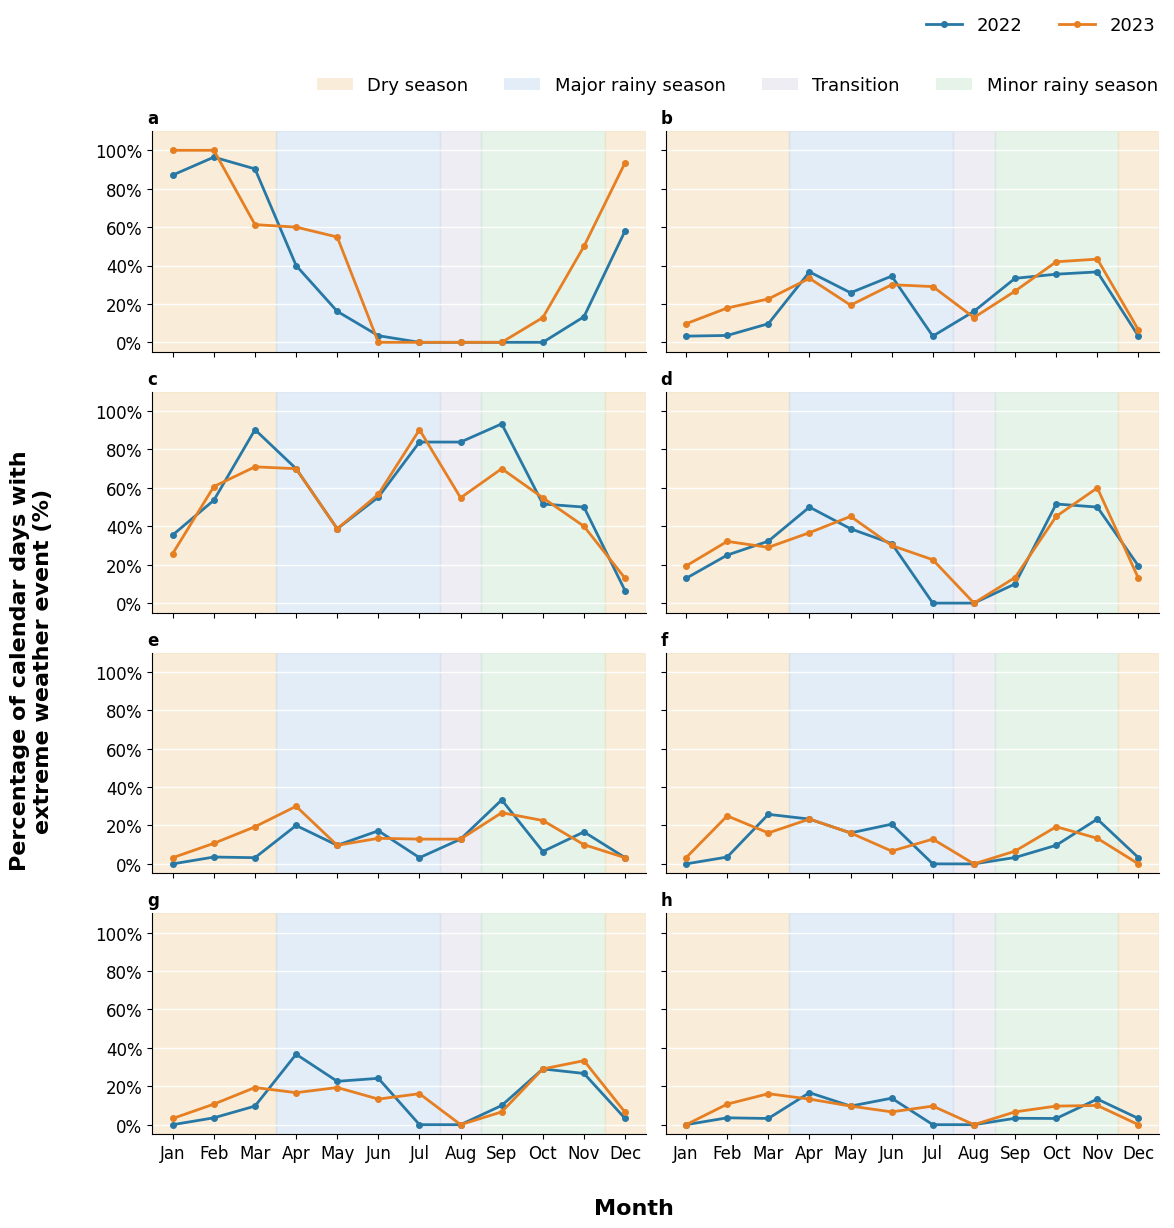

In [72]:
fig, axes = plot_monthly_extreme_event_panels_by_year(
    monthly_all_events_by_year,

    event_order=[
        "T", "P",
        "W", "L",
        "PW", "WL",
        "PL", "PWL",
    ],
    panel_labels=list("abcdefgh"),

    figsize=(12, 12),

    # Different line colors for each year
    year_colors={
        2022: "#2878A5",
        2023: "#E67E22",
    },
    marker="o",
    linewidth=2,
    markersize=4,

    # Y-axis
    ylim=(-5, 110),
    show_y_percent_sign=True,
    y_percent_decimals=0,

    # Tick labels
    x_tick_fontsize=12,
    y_tick_fontsize=12,

    # Shared axis labels
    shared_xlabel="Month",
    shared_ylabel=(
        "Percentage of calendar days with\n"
        "extreme weather event (%)"
    ),
    xlabel_x=0.55,
    xlabel_y=0.035,
    ylabel_x=0.048,
    ylabel_y=0.5,
    xlabel_fontsize=16,
    ylabel_fontsize=16,
    xlabel_fontweight="bold",
    ylabel_fontweight="bold",

    # Panel labels
    panel_label_x=-0.01,
    panel_label_y=1.10,
    panel_label_fontsize=12,
    panel_label_fontweight="bold",

    # Seasonal styling
    season_colors={
        "Dry season": "#F4DDB5",
        "Major rainy season": "#C8DCF0",
        "Transition": "#DDDDE8",
        "Minor rainy season": "#CFE8D5",
    },
    season_alpha=0.5,

    # Year legend
    show_year_legend=True,
    year_legend_loc="upper left",
    year_legend_bbox=(.78,1.05),
    year_legend_ncol=2,
    year_legend_fontsize=13,

    # Season legend
    show_season_legend=True,
    season_legend_loc="upper right",
    # season_legend_bbox=None,
    season_legend_bbox=(1,1),
    season_legend_ncol=4,
    season_legend_fontsize=13,

    # Layout
    tight_layout_rect=(0.04, 0.04, 1, 0.97),

    # Save
    save_path=(
        PLOTS_DIR
        / "monthly_extreme_event_panels_by_year.png"
    ),
    dpi=300,
)

In [73]:
# monthly_all_events_by_year[ (monthly_all_events_by_year['Year']==2023) & (monthly_all_events_by_year['Event']=='T')]

In [74]:
# monthly_all_events_by_year[ (monthly_all_events_by_year['Year']==2022) & (monthly_all_events_by_year['Event']=='W')]

In [75]:
# monthly_all_events_by_year[ (monthly_all_events_by_year['Year']==2023) & (monthly_all_events_by_year['Event']=='W')]

### Get the numbers 

In [76]:
p_results = (
    monthly_all_events_by_year
    .loc[monthly_all_events_by_year["Event"].eq("P")]
    .sort_values("pct_days_extreme", ascending=False)
    .reset_index(drop=True)
)

In [77]:
# p_results

In [78]:
l_results = (
    monthly_all_events_by_year
    .loc[monthly_all_events_by_year["Event"].eq("L")]
    .sort_values("pct_days_extreme", ascending=False)
    .reset_index(drop=True)
)

In [79]:
# l_results